In [63]:

import os, types
import pandas as pd
from botocore.client import Config
import ibm_boto3

def __iter__(self): return 0

# @hidden_cell
# The following code accesses a file in your IBM Cloud Object Storage. It includes your credentials.
# You might want to remove those credentials before you share the notebook.

cos_client = ibm_boto3.client(service_name='s3',
    ibm_api_key_id='_KuZcjCbvN3RZZpmuzOs0VydtttYd0wdZJmLpl3MjZmj',
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version='oauth'),
    endpoint_url='https://s3.direct.us-south.cloud-object-storage.appdomain.cloud')

bucket = 'powersystemfaultdetection-donotdelete-pr-rnpwuoyurziptp'
object_key = 'fault_data.csv'

body = cos_client.get_object(Bucket=bucket,Key=object_key)['Body']
# add missing __iter__ method, so pandas accepts body as file-like object
if not hasattr(body, "__iter__"): body.__iter__ = types.MethodType( __iter__, body )

df_1 = pd.read_csv(body)
df_1.head(10)


,Fault ID,Fault Type,"Fault Location (Latitude, Longitude)",Voltage (V),Current (A),Power Load (MW),Temperature (°C),Wind Speed (km/h),Weather Condition,Maintenance Status,Component Health,Duration of Fault (hrs),Down time (hrs)
0,F001,Line Breakage,"(34.0522, -118.2437)",2200,250,50,25,20,Clear,Scheduled,Normal,2.0,1.0
1,F002,Transformer Failure,"(34.056, -118.245)",1800,180,45,28,15,Rainy,Completed,Faulty,3.0,5.0
2,F003,Overheating,"(34.0525, -118.244)",2100,230,55,35,25,Windstorm,Pending,Overheated,4.0,6.0
3,F004,Line Breakage,"(34.055, -118.242)",2050,240,48,23,10,Clear,Completed,Normal,2.5,3.0
4,F005,Transformer Failure,"(34.0545, -118.243)",1900,190,50,30,18,Snowy,Scheduled,Faulty,3.5,4.0
5,F006,Overheating,"(34.05, -118.24)",2150,220,52,32,22,Thunderstorm,Pending,Overheated,5.0,7.0
6,F007,Line Breakage,"(34.9449, -118.9839)",1994,233,51,23,21,Snowy,Completed,Normal,3.7,6.1
7,F008,Transformer Failure,"(34.2294, -118.2988)",2133,229,52,20,18,Snowy,Scheduled,Normal,5.4,2.1
8,F009,Line Breakage,"(34.1279, -118.8442)",2155,240,45,21,29,Rainy,Pending,Overheated,3.2,4.7
9,F010,Line Breakage,"(34.4192, -118.8254)",2065,199,55,25,21,Clear,Scheduled,Normal,4.0,2.8


In [39]:
df = df_1.copy()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (506, 13)

Columns:
Index(['Fault ID', 'Fault Type', 'Fault Location (Latitude, Longitude)',
       'Voltage (V)', 'Current (A)', 'Power Load (MW)', 'Temperature (°C)',
       'Wind Speed (km/h)', 'Weather Condition', 'Maintenance Status',
       'Component Health', 'Duration of Fault (hrs)', 'Down time (hrs)'],
      dtype='object')


,Fault ID,Fault Type,"Fault Location (Latitude, Longitude)",Voltage (V),Current (A),Power Load (MW),Temperature (°C),Wind Speed (km/h),Weather Condition,Maintenance Status,Component Health,Duration of Fault (hrs),Down time (hrs)
0,F001,Line Breakage,"(34.0522, -118.2437)",2200,250,50,25,20,Clear,Scheduled,Normal,2.0,1.0
1,F002,Transformer Failure,"(34.056, -118.245)",1800,180,45,28,15,Rainy,Completed,Faulty,3.0,5.0
2,F003,Overheating,"(34.0525, -118.244)",2100,230,55,35,25,Windstorm,Pending,Overheated,4.0,6.0
3,F004,Line Breakage,"(34.055, -118.242)",2050,240,48,23,10,Clear,Completed,Normal,2.5,3.0
4,F005,Transformer Failure,"(34.0545, -118.243)",1900,190,50,30,18,Snowy,Scheduled,Faulty,3.5,4.0


In [40]:
print(df['Fault Type'].value_counts())

Fault Type
Transformer Failure    171
Overheating            171
Line Breakage          164
Name: count, dtype: int64


In [41]:
print(df.isnull().sum())

Fault ID                                0
Fault Type                              0
Fault Location (Latitude, Longitude)    0
Voltage (V)                             0
Current (A)                             0
Power Load (MW)                         0
Temperature (°C)                        0
Wind Speed (km/h)                       0
Weather Condition                       0
Maintenance Status                      0
Component Health                        0
Duration of Fault (hrs)                 0
Down time (hrs)                         0
dtype: int64


In [42]:
print(df.columns)

Index(['Fault ID', 'Fault Type', 'Fault Location (Latitude, Longitude)',
       'Voltage (V)', 'Current (A)', 'Power Load (MW)', 'Temperature (°C)',
       'Wind Speed (km/h)', 'Weather Condition', 'Maintenance Status',
       'Component Health', 'Duration of Fault (hrs)', 'Down time (hrs)'],
      dtype='object')


In [43]:
print(df['Fault Type'].value_counts())

Fault Type
Transformer Failure    171
Overheating            171
Line Breakage          164
Name: count, dtype: int64


In [44]:
df = df_1.copy()

# Remove ID column
df.drop('Fault ID', axis=1, inplace=True)

# Check missing values
print(df.isnull().sum())

Fault Type                              0
Fault Location (Latitude, Longitude)    0
Voltage (V)                             0
Current (A)                             0
Power Load (MW)                         0
Temperature (°C)                        0
Wind Speed (km/h)                       0
Weather Condition                       0
Maintenance Status                      0
Component Health                        0
Duration of Fault (hrs)                 0
Down time (hrs)                         0
dtype: int64


In [45]:
print(df.dtypes)

Fault Type                               object
Fault Location (Latitude, Longitude)     object
Voltage (V)                               int64
Current (A)                               int64
Power Load (MW)                           int64
Temperature (°C)                          int64
Wind Speed (km/h)                         int64
Weather Condition                        object
Maintenance Status                       object
Component Health                         object
Duration of Fault (hrs)                 float64
Down time (hrs)                         float64
dtype: object


In [46]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

# Encode categorical columns
categorical_cols = [
    'Fault Location (Latitude, Longitude)',
    'Weather Condition',
    'Maintenance Status',
    'Component Health'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le

# Encode target column
target_encoder = LabelEncoder()
df_ml['Fault Type'] = target_encoder.fit_transform(df_ml['Fault Type'])

print(df_ml.head())

   Fault Type  Fault Location (Latitude, Longitude)  Voltage (V)  Current (A)  \
0           0                                    25         2200          250   
1           2                                    30         1800          180   
2           1                                    26         2100          230   
3           0                                    29         2050          240   
4           2                                    28         1900          190   

   Power Load (MW)  Temperature (°C)  Wind Speed (km/h)  Weather Condition  \
0               50                25                 20                  0   
1               45                28                 15                  1   
2               55                35                 25                  4   
3               48                23                 10                  0   
4               50                30                 18                  2   

   Maintenance Status  Component Health  Dur

In [47]:
X = df_ml.drop('Fault Type', axis=1)
y = df_ml['Fault Type']

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (506, 11)
Y Shape: (506,)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 404
Testing samples: 102


In [49]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [50]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 32.35294117647059


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.26      0.18      0.21        33
           1       0.33      0.37      0.35        35
           2       0.36      0.41      0.38        34

    accuracy                           0.32       102
   macro avg       0.31      0.32      0.31       102
weighted avg       0.32      0.32      0.32       102



In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.26      0.18      0.21        33
           1       0.33      0.37      0.35        35
           2       0.36      0.41      0.38        34

    accuracy                           0.32       102
   macro avg       0.31      0.32      0.31       102
weighted avg       0.32      0.32      0.32       102



In [53]:
print(df.groupby('Fault Type').mean(numeric_only=True))

                     Voltage (V)  Current (A)  Power Load (MW)  \
Fault Type                                                       
Line Breakage        2045.493902   214.969512        50.304878   
Overheating          2061.286550   217.046784        49.397661   
Transformer Failure  2041.959064   217.298246        50.345029   

                     Temperature (°C)  Wind Speed (km/h)  \
Fault Type                                                 
Line Breakage               30.048780          19.500000   
Overheating                 29.918129          20.198830   
Transformer Failure         30.526316          19.508772   

                     Duration of Fault (hrs)  Down time (hrs)  
Fault Type                                                     
Line Breakage                       3.847561         3.892073  
Overheating                         4.080117         4.041520  
Transformer Failure                 4.090058         4.061404  


In [54]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

                                 Feature  Importance
0   Fault Location (Latitude, Longitude)    0.129919
1                            Voltage (V)    0.125653
2                            Current (A)    0.122555
10                       Down time (hrs)    0.111668
9                Duration of Fault (hrs)    0.109513
4                       Temperature (°C)    0.098663
5                      Wind Speed (km/h)    0.095498
3                        Power Load (MW)    0.078048
6                      Weather Condition    0.055003
8                       Component Health    0.038314
7                     Maintenance Status    0.035166


In [55]:
!pip install xgboost -q

In [56]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb)*100)

Accuracy: 37.254901960784316


In [57]:
import joblib

joblib.dump(xgb, "fault_model.pkl")

print("Model saved successfully")

Model saved successfully


In [58]:
joblib.dump(encoders, "encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

['target_encoder.pkl']

In [59]:
!ls

encoders.pkl  fault_model.pkl  target_encoder.pkl


In [60]:
project.save_data(
    file_name="fault_model.pkl",
    data=open("fault_model.pkl", "rb"),
    overwrite=True
)

NameError: name 'project' is not defined

In [ ]:
!ls -lh

In [ ]:
!pwd

In [ ]:
import joblib

model = joblib.load("fault_model.pkl")

sample = X_test.iloc[[0]]

prediction = model.predict(sample)

fault = target_encoder.inverse_transform(prediction)

print("Predicted Fault:", fault[0])

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr

print(gr.__version__)

In [ ]:
import joblib

# Load saved model
model = joblib.load("fault_model.pkl")

print("Model Loaded Successfully")

In [ ]:
print(target_encoder.classes_)

In [ ]:
import pandas as pd

def predict_fault(
    location,
    voltage,
    current,
    power_load,
    temperature,
    wind_speed,
    weather,
    maintenance,
    component_health,
    duration,
    downtime
):

    # Encode categorical columns
    location = encoders['Fault Location (Latitude, Longitude)'].transform([location])[0]
    weather = encoders['Weather Condition'].transform([weather])[0]
    maintenance = encoders['Maintenance Status'].transform([maintenance])[0]
    component_health = encoders['Component Health'].transform([component_health])[0]

    sample = pd.DataFrame([[
        location,
        voltage,
        current,
        power_load,
        temperature,
        wind_speed,
        weather,
        maintenance,
        component_health,
        duration,
        downtime
    ]], columns=X.columns)

    prediction = model.predict(sample)

    result = target_encoder.inverse_transform(prediction)

    return result[0]

In [ ]:
for col in encoders:
    print(col)
    print(encoders[col].classes_)
    print()

In [ ]:
import gradio as gr

demo = gr.Interface(
    fn=predict_fault,

    inputs=[
        gr.Dropdown(
            choices=list(encoders['Fault Location (Latitude, Longitude)'].classes_),
            label="Location"
        ),

        gr.Number(label="Voltage"),

        gr.Number(label="Current"),

        gr.Number(label="Power Load"),

        gr.Number(label="Temperature"),

        gr.Number(label="Wind Speed"),

        gr.Dropdown(
            choices=list(encoders['Weather Condition'].classes_),
            label="Weather"
        ),

        gr.Dropdown(
            choices=list(encoders['Maintenance Status'].classes_),
            label="Maintenance Status"
        ),

        gr.Dropdown(
            choices=list(encoders['Component Health'].classes_),
            label="Component Health"
        ),

        gr.Number(label="Duration of Fault"),

        gr.Number(label="Downtime")
    ],

    outputs="text",

    title="Power System Fault Detection",

    description="Predict Fault Type using Machine Learning"
)

demo.launch()

In [62]:
import gradio as gr
import pandas as pd
import joblib

# Load model
model = joblib.load("fault_model.pkl")

def predict_fault(
    voltage,
    current,
    power_load,
    temperature,
    wind_speed,
    weather,
    maintenance,
    component_health,
    duration,
    downtime
):

    # Use first location value as default
    location = encoders['Fault Location (Latitude, Longitude)'].transform(
        [encoders['Fault Location (Latitude, Longitude)'].classes_[0]]
    )[0]

    weather = encoders['Weather Condition'].transform([weather])[0]
    maintenance = encoders['Maintenance Status'].transform([maintenance])[0]
    component_health = encoders['Component Health'].transform([component_health])[0]

    sample = pd.DataFrame([[
        location,
        voltage,
        current,
        power_load,
        temperature,
        wind_speed,
        weather,
        maintenance,
        component_health,
        duration,
        downtime
    ]], columns=X.columns)

    pred = model.predict(sample)

    return target_encoder.inverse_transform(pred)[0]


demo = gr.Interface(
    fn=predict_fault,
    inputs=[
        gr.Number(label="Voltage (V)", value=2050),
        gr.Number(label="Current (A)", value=215),
        gr.Number(label="Power Load (MW)", value=50),
        gr.Number(label="Temperature (°C)", value=30),
        gr.Number(label="Wind Speed (km/h)", value=20),

        gr.Dropdown(
            ["Clear", "Rainy", "Snowy", "Thunderstorm", "Windstorm"],
            label="Weather Condition"
        ),

        gr.Dropdown(
            ["Completed", "Pending", "Scheduled"],
            label="Maintenance Status"
        ),

        gr.Dropdown(
            ["Faulty", "Normal", "Overheated"],
            label="Component Health"
        ),

        gr.Number(label="Duration of Fault (hrs)", value=4),
        gr.Number(label="Down Time (hrs)", value=4)
    ],

    outputs=gr.Textbox(label="Predicted Fault Type"),

    title="Power System Fault Detection and Classification",

    description="IBM Cloud + Machine Learning Demo"
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://1acaf6d9ce28e8aa0c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [61]:
cos_client = ibm_boto3.client(...)
df_1 = pd.read_csv(body)
df_1.head()

AttributeError: 'ellipsis' object has no attribute 'replace'

In [64]:
sample = X_test.iloc[[0]]

prediction = xgb.predict(sample)

print("Input Data:")
print(sample)

print("\nPredicted Fault:")
print(target_encoder.inverse_transform(prediction)[0])

Input Data:
     Fault Location (Latitude, Longitude)  Voltage (V)  Current (A)  \
335                                   263         1899          205   

     Power Load (MW)  Temperature (°C)  Wind Speed (km/h)  Weather Condition  \
335               48                34                 17                  0   

     Maintenance Status  Component Health  Duration of Fault (hrs)  \
335                   2                 0                      3.4   

     Down time (hrs)  
335              6.6  

Predicted Fault:
Transformer Failure


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.37      0.33      0.35        33
           1       0.38      0.31      0.34        35
           2       0.37      0.47      0.42        34

    accuracy                           0.37       102
   macro avg       0.37      0.37      0.37       102
weighted avg       0.37      0.37      0.37       102



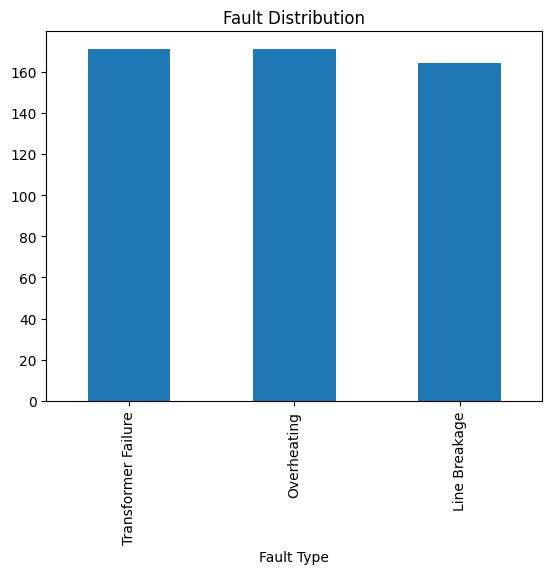

In [67]:
import matplotlib.pyplot as plt

df['Fault Type'].value_counts().plot(kind='bar')
plt.title("Fault Distribution")
plt.show()

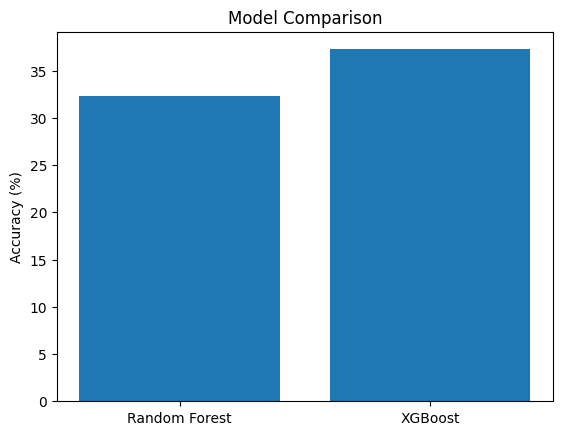

In [68]:
import matplotlib.pyplot as plt

models = ['Random Forest','XGBoost']
accuracy = [32.35,37.25]

plt.bar(models,accuracy)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.show()